<span style="font-size:10pt">DIADEM course "Deep Learning - Image Classification" / Mai 20-21, 2026<br> 
v1.0  - CC BY-SA 4.0 Jean-Luc CHARLES (Jean-Luc.charles@mailo.com)</span>

<div class="alert alert-block alert-danger">
<span style="color:brown;font-family:arial;font-size:normal">
     It is important to define a <span style="font-weight:bold;">Python Virtual Environment</span> (PVE) for each Python project: 
     a PVE makes it possible to control for each project the versions of the Python interpreter and “sensitive” modules (tensorflow...).<br>

- a KAGGLE session can serve as a PVE,
- or if you run a local machine, use the `uv` manager to create a PVE and run the notenbook with teh command `uv run jupyter lab` to ensure it uses the PVE of the projet.

<span style="font-family:arial;font-size:1cm;">
    Machine learning with tensorflow2/keras Python modules
</span>

# Training a simple Dense Neural Network to classify small images

## 0 - Preliminaries

### Configure KAGGLE environment if needed

Run the next cell if you are working within a KAGGLE session, to configure your kaggle environment.<br>
If you run it while not within a kaggke session it wil do nothing.

In [1]:
import sys
from pathlib import Path

if 'kaggle' in Path.cwd().as_posix():
    KAGGLE = True
    print(f'Notebook running on KAGGLE')
else:
    KAGGLE = False
    print(f'Notebook not running on KAGGLE')

if KAGGLE:
    #
    # Add the path to the <utils> directory to the sys.path list:
    #
    paths = list(Path('/kaggle').rglob('utils'))
    if len(paths) == 0:
        print('\tNo <utils> directory found in your workspace, sorry.')
    else:
        util_path = paths[0].parent.as_posix()
        sys.path.append(util_path)
        print(f'\t<{util_path}> added to sys.path.')
    #
    # Create a link <img> to the image directory of the dataset éDL img"
    #
    img_dataset_path = Path('/kaggle/input/datasets/jlcharles/dl-img')
    link_to_img_dir  = Path.cwd() / 'img'
    if not link_to_img_dir.is_symlink(): 
        link_to_img_dir.symlink_to(img_dataset_path)
    print(f'\tlink <{link_to_img_dir}> to <{img_dataset_path}> OK')

Notebook not running on KAGGLE


If within a KAGGLE session you must install the GPUtil module:

In [2]:
! test $(pwd) = '/kaggle/working' && pip install GPUtil

### Import the Python modules

In [3]:
# suppress tensorflow verbose warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [4]:
# Deep Learning modules:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report

# General modules:
import numpy as np
import matplotlib.pyplot as plt
from time import time
from pathlib import Path
from cpuinfo import get_cpu_info
import GPUtil
import sys
import random
import cv2

# Custom modules:
from utils.tools import elapsed_time_since, cpu_gpu, plot_loss_accuracy

E0000 00:00:1775407094.503210  719506 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775407094.508817  719506 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775407094.523820  719506 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775407094.523842  719506 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775407094.523844  719506 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775407094.523845  719506 computation_placer.cc:177] computation placer already registered. Please check linka

In [5]:
print(f"Python    : {sys.version.split()[0]}")
print(f"tensorflow: {tf.__version__} with keras {keras.__version__}")
print(f"numpy     : {np.__version__}")
print(f"OpenCV    : {cv2.__version__}")

Python    : 3.12.12
tensorflow: 2.19.0 with keras 3.14.0
numpy     : 2.1.3
OpenCV    : 4.13.0


In [6]:
# allows to visualize the graphs directly in the cell of the N.B.
%matplotlib inline

# SEED will be used to fix the _seed_ of the random generators to have continuations
# of repeatable random numbers
SEED = 1234

tf.get_logger().setLevel('ERROR')

#### Check wether GPU is available for tensorflow or not:

In [7]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
else:
    print("No GPU found, only CPU.")

No GPU found, only CPU.


### Create the `models` directory

In [8]:
print(f'{"WORKING DIRECTORY":20s}: {Path.cwd()}')
model_path = Path("./models")
model_path.mkdir(exist_ok=True)
print(f'{"MODELS DIRECTORY":20s}: {model_path.absolute().as_posix()}')

WORKING DIRECTORY   : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks
MODELS DIRECTORY    : /home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/Notebooks/models


## 1 - Prepare the MNIST dataset (images and labels)

### Load the MNIST dataset

We use the keras `load_data` function to load the data from the MNIST 
(see [tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)):<br>
- `train_img`, `train_lab` are the training images and labels,
- `valid_img`, `valid_lab` are the validation images and labels.

In [9]:
(train_img, train_lab), (valid_img, valid_lab) = keras.datasets.mnist.load_data()

Let's check the `shape` and `dtype` attributes of the numpy arrays:

In [10]:
print(f"train_img.shape: {train_img.shape}, dtype: {train_img.dtype}")
print(f"train_lab.shape: {train_lab.shape}, dtype: {train_lab.dtype}")
print(f"valid_img.shape: {valid_img.shape}, dtype: {valid_img.dtype}")
print(f"lab_vaild.shape: {valid_lab.shape}, dtype: {valid_lab.dtype}")

train_img.shape: (60000, 28, 28), dtype: uint8
train_lab.shape: (60000,), dtype: uint8
valid_img.shape: (10000, 28, 28), dtype: uint8
lab_vaild.shape: (10000,), dtype: uint8


### Visualize of images and labels:

The local module `utils.tools` defines the `plot_images` function which can be used to display a grid of MNIST images.<br>
Let's plot a grid of images 3 x 10 beginning with the 600th image:

In [11]:
from utils.tools import plot_images
help(plot_images)

Help on function plot_images in module utils.tools:

plot_images(image_array: numpy.ndarray, R: int, C: int, r: int = 0, figsize: tuple = None, label_array: numpy.ndarray = None, reverse: bool = False, ret: bool = False)
    Plot the images from image_array on a R x C grid, starting at image rank r.
    Arguments:
       image_array: an array of images
       R: the number of rows
       C: the number of columns
       r: the starting rank in the array image_array (default: 0)
       figsize: the sise of the display (default: (C//2+1, R//2+1))
       label_array: an optional array of labels to give the imshow title
       reverse: wether to reverse video the image or not (default: False)
       ret: wether to return the fig or not (useful for marimo)



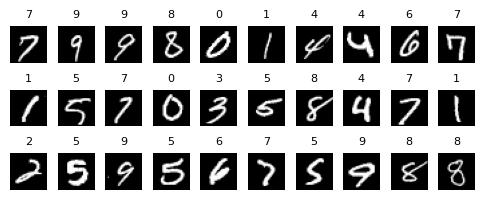

In [12]:
plot_images(train_img, R=3, C=10, r=599, label_array=train_lab)

### Create the 3 datasets: train, validation & test

To follow the _state of the art_, we will split the dataset into train, validation & test datasets.<br>
A simple way to do this is to keep the train dataset and to split the current validation dataset in two equal subsets:
- a new smaller validation subset,
- a new test subset.<br>

We use the function `train_test_split` form the `sklearn` module:

In [13]:
from sklearn.model_selection import train_test_split
valid_img, test_img, valid_lab, test_lab = train_test_split(valid_img, valid_lab,
                                                            stratify=valid_lab,
                                                            test_size=0.5,
                                                            shuffle=True,
                                                            random_state=SEED)

Let's check the sizes of the 3 datasets:

In [14]:
print(f'train:  {train_img.shape}')
print(f'valid:  {valid_img.shape}')
print(f'test :  {test_img.shape}')

train:  (60000, 28, 28)
valid:  (5000, 28, 28)
test :  (5000, 28, 28)


We can verify that the proportion of digits remains homogenous in all the datasets thanks to the `plot_proportion_bar` of the `utils.tools` module:

In [15]:
from utils.tools import plot_proportion_bar
help(plot_proportion_bar)

Help on function plot_proportion_bar in module utils.tools:

plot_proportion_bar(proportions: dict, class_names, figsize=(6, 4), ret: bool = False)
    To plot propotion of classes in different datasets.
    proportion: the dictionnary {<dataset name>: <[number of class in teh dataset]>}



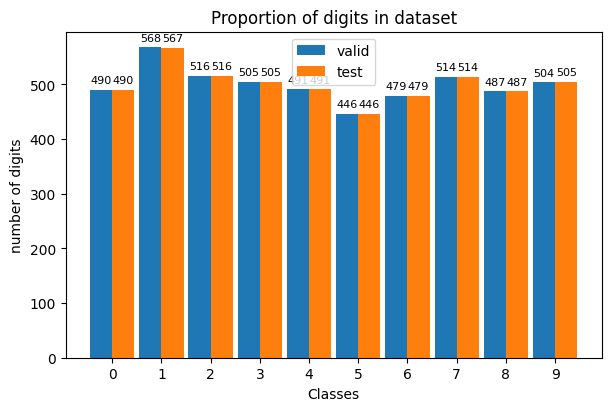

In [16]:
from utils.tools import plot_proportion_bar
prop = {}
prop['valid'] = [ (valid_lab == i).sum() for i in range(10)]
prop['test']  = [ (test_lab  == i).sum() for i in range(10)]
plot_proportion_bar(prop, range(10))

## 2 -  Define important parameters

To avoid hard-coding the number of training, valid and test images as well as the size of the images, these parameters are recovered from the data set:
- with the shape attribute of the `train_img` and `test_im` arrays
- with the size attribute of the first training image for example


In [17]:
NB_TRAIN_IMG = train_img.shape[0]  # number of training images
NB_VALID_IMG = valid_img.shape[0]  # number of validation images 
NB_TEST_IMG  = test_img.shape[0]   # number of test images
NB_PIXEL     = train_img[0].size   # number of elements (pixels) of the firts training image: 
NB_CLASS     = len(set(train_lab)) # number of classes:

# Display checking:
print(f"{NB_TRAIN_IMG} training images, {NB_VALID_IMG} validation images and {NB_TEST_IMG} test images")
print(f"{train_img.shape[1]}x{train_img.shape[2]}={NB_PIXEL} pixels in each image")
print(f"{NB_CLASS} classes found in the `train_lab` ndarray")

60000 training images, 5000 validation images and 5000 test images
28x28=784 pixels in each image
10 classes found in the `train_lab` ndarray


## 3 - Process input data

Two treatments must be applied to the data from the MNIST database:
- **on images**: transform the matrices of  28$\,\times\,$28 pixels (`uint8`integers) into **normalized** vectors $(V_i)_{i=0..783}$ of 784 real values $V_i$ with $ 0 \leqslant V_i \leqslant 1$;
- **on labels**: transform scalar numbers into *one-hot* vectors.

### 3.1 - Transform input matrices into normalized vectors

We define the arrays `x_train`, `x_valid` and `x_test` containing the matrices of the arrays `train_img`, `valid_img` and `test_img` *flattened* as normalized vectors (values between 0 and 1):

In [18]:
x_train = train_img.reshape(NB_TRAIN_IMG, NB_PIXEL)/255
x_valid = valid_img.reshape(NB_VALID_IMG, NB_PIXEL)/255
x_test  = test_img.reshape(NB_TEST_IMG, NB_PIXEL)/255

#check:
print(f'train: {x_train.shape}, min: {x_train.min()}, max: {x_train.max()}')
print(f'valid: {x_valid.shape}, min: {x_valid.min()}, max: {x_valid.max()}')
print(f'test : {x_test.shape}, min: {x_test.min()}, max: {x_test.max()}')

train: (60000, 784), min: 0.0, max: 1.0
valid: (5000, 784), min: 0.0, max: 1.0
test : (5000, 784), min: 0.0, max: 1.0


### 3.2 - *one-hot* encoding of labels

We use the **keras** `to_categorical` function (see [tf.keras.utils.to_categorical](https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical)) to define the `y_train` and `y_valid` arrays containing the *hot-one* encoded version of `lab_train` and `lab_valid`:

In [19]:
from tensorflow.keras.utils import to_categorical
# 'one-hot' encoding' of labels :
y_train = to_categorical(train_lab)
y_valid = to_categorical(valid_lab)
y_test  = to_categorical(test_lab)

Let's check the first 10 values of the `lab_train` and `y_train` arrays:

In [20]:
print(train_lab[:10])
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## 4 - Build the Dense Neural Network (DNN)

 To get short computation times we build a simple dense network to classify the MNIST images.<br>
 Of course, this is not the "state of the art" : convolutive NN, transformers have much more impressive scores, but we just want want short training computation time.<br><br>
We buildthis naive **dense network**:
- an **input layer** of 784 values (the pixels of the MNIST 28 $\times$ 28 images flattened in the form of a vector of 784 normalized `float` numbers),
- a **hidden layer** of 784 neurons using the `relu` activation function,
- an **output layer** of 10 neurons, for the classification of the 10 digits {0,1,2...9}, using the `softmax` activation function adapted to classification problems .

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/Simple-DNN.png" alt="Simple-DNN.png" style="width:900px;"><br>
     [image credit: JLC]

In [21]:
NB_INPUT  = NB_PIXEL
NB_NEURON = NB_PIXEL

For the sake of convenience we défine a function to build the NN: 

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def build_DNN(seed=None, name=''):

    if seed is not None:
        ##########################
        # Deterministic training #
        ##########################
        # 1/ set the seed of the random generators involved by tensorflow:
        tf.keras.utils.set_random_seed(seed)
        # 2/ make the tf ops determinisctic 
        # [see https://blog.tensorflow.org/2022/05/whats-new-in-tensorflow-29.html]
        tf.config.experimental.enable_op_determinism() 

    model = Sequential()
    model.add(Input(shape=(NB_INPUT,), name='input'))             # INPUT layer
    model.add(Dense(NB_NEURON, activation='relu', name='c1'))     # First hidden layer
    model.add(Dense(NB_CLASS, activation='softmax', name='c2'))   # OUTPUT layer
   
    model.compile(loss='categorical_crossentropy', optimizer='adam',  metrics=['accuracy'])
    
    if name: model.name = name
    return model

Lets's look at the number of _parameters_ (the _weights_) of the model:

In [23]:
model = build_DNN()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ c1 (Dense)                      │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c2 (Dense)                      │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

## 5 - Elementary tests of the reproducibility of the DNN training...

Perfect reproducibility of a neural network training may be difficult to achieve with tensorflow...<br>
To highlight the question of reproducibility we run a short experiment: <br>
$\leadsto$ run a loop where the model is built without setting the seed, trained and evaluated once (_epochs=1_) at each iteration.

#### A/ Build the model at each loop lap without SEED: training not reproducible

In [24]:
print(cpu_gpu())
for _ in range(5):
    model = build_DNN()  # Build a new model without setting seed
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1879 - val_accuracy: 0.9666 - val_loss: 0.1038
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1908 - val_accuracy: 0.9636 - val_loss: 0.1190
1875/1875 - 8s - 4ms/step - accuracy: 0.9451 - loss: 0.1885 - val_accuracy: 0.9716 - val_loss: 0.0964
1875/1875 - 8s - 4ms/step - accuracy: 0.9451 - loss: 0.1880 - val_accuracy: 0.9716 - val_loss: 0.0934
1875/1875 - 8s - 4ms/step - accuracy: 0.9433 - loss: 0.1892 - val_accuracy: 0.9708 - val_loss: 0.0940


If we repeat 5 times the first epoch of the training, the `val_accuracy`and `val_loss` differ at each iteration $\leadsto$ the training is not reproducible.

#### B/ Build a model once witout SEED and reload the weights at each loop lap: training not reproducible

We save the weights of a model built without setting the seed:

In [25]:
model = build_DNN()
model.save_weights('models/DNN_noseed.weights.h5')

In [26]:
print(cpu_gpu())
for _ in range(5):
    model.load_weights('models/DNN_noseed.weights.h5') # reload the inital model weights
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
1875/1875 - 7s - 4ms/step - accuracy: 0.9432 - loss: 0.1915 - val_accuracy: 0.9736 - val_loss: 0.0924


/home/jlc/work/IA-MachineLearning/18-DIADEM/DL_DIADEM/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1875/1875 - 7s - 4ms/step - accuracy: 0.9469 - loss: 0.1762 - val_accuracy: 0.9696 - val_loss: 0.0877
1875/1875 - 7s - 4ms/step - accuracy: 0.9470 - loss: 0.1753 - val_accuracy: 0.9748 - val_loss: 0.0859
1875/1875 - 7s - 4ms/step - accuracy: 0.9478 - loss: 0.1730 - val_accuracy: 0.9698 - val_loss: 0.0972
1875/1875 - 7s - 4ms/step - accuracy: 0.9482 - loss: 0.1722 - val_accuracy: 0.9754 - val_loss: 0.0816


The `val_loss` is still non-reproducible.

#### C/ Build the model with SEED at each loop lap: training perfectly reproducible

In [27]:
print(cpu_gpu())
for _ in range(5):
    model = build_DNN(seed=1234)  # Build a new model with seed set
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 7s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180


If we set the seed when creating the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible &#128526;.

#### D/ Build the model with SEED  and load the model's structure & initial at each loop lap: training perfectly reproducible

In [28]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234.keras')

In [29]:
print(cpu_gpu())
for _ in range(5):
    model = tf.keras.models.load_model('models/DNN_seed1234.keras') # reload the model structure & weights 
    hist = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_valid, y_valid), verbose=2)    

CPU [11th Gen Intel(R) Core(TM) i7-1165G7 @ 2.80GHz]
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
1875/1875 - 8s - 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180


If we load the structure and the weights of the model at each iteration the `val_accuracy`and `val_loss` are perfectly reproducible  &#128526;.

<span style="color:brown">We can ensure the reproducibility of the first epoch of the training:<br>
$\leadsto$ by setting the seed at the model creation (and everywhere else where required)<br>
$\leadsto$ by reloading the entire network structure and weights with the __tf.keras.models.load_model__ function<br><br>
</spawn>

## 6 - Adressing the reproducibility of the DNN training...

### A - Run several trainings with a new model (no SEED) at each iteration $\leadsto$ not reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_noSEED_epochs10_bs32.png" alt="range5_noSEED_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

training #1
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9421 - loss: 0.1910 - val_accuracy: 0.9720 - val_loss: 0.0894
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9769 - loss: 0.0751 - val_accuracy: 0.9802 - val_loss: 0.0701
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9845 - loss: 0.0505 - val_accuracy: 0.9778 - val_loss: 0.0715
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9798 - val_loss: 0.0707
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9916 - loss: 0.0259 - val_accuracy: 0.9796 - val_loss: 0.0802
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9925 - loss: 0.0221 - val_accuracy: 0.9782 - val_loss: 0.0797
training #2
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9443 - loss: 0.1895 - val_accuracy: 0.9712 - val_loss: 0.0960
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9772 -

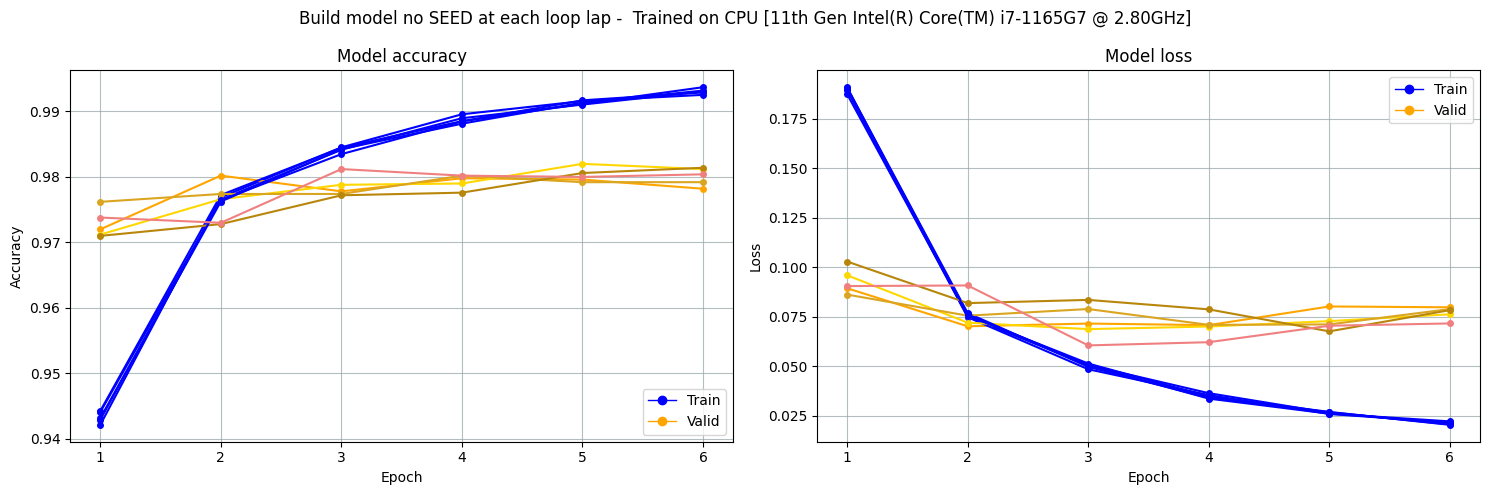

In [24]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
    model = build_DNN()                # build a new network, no SEED given
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=6,        # the total number of successive trainings
                     batch_size=32,    # split the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   
plot_loss_accuracy(H, message='Build model no SEED at each loop lap')

The `val_loss` and `val_accuracy` differ at each of the training.<br>
It can be a problem if we train the model with a _callback_ like __early stoppping__ : the training will stop at a different epoch if we run the training many times.

### B - New model with SEED at each loop lap: $\leadsto$ reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_SEED1234_epochs10_bs32.png" alt="range5_SEED1234_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

training #1
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9776 - val_loss: 0.0968
training #2
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 -

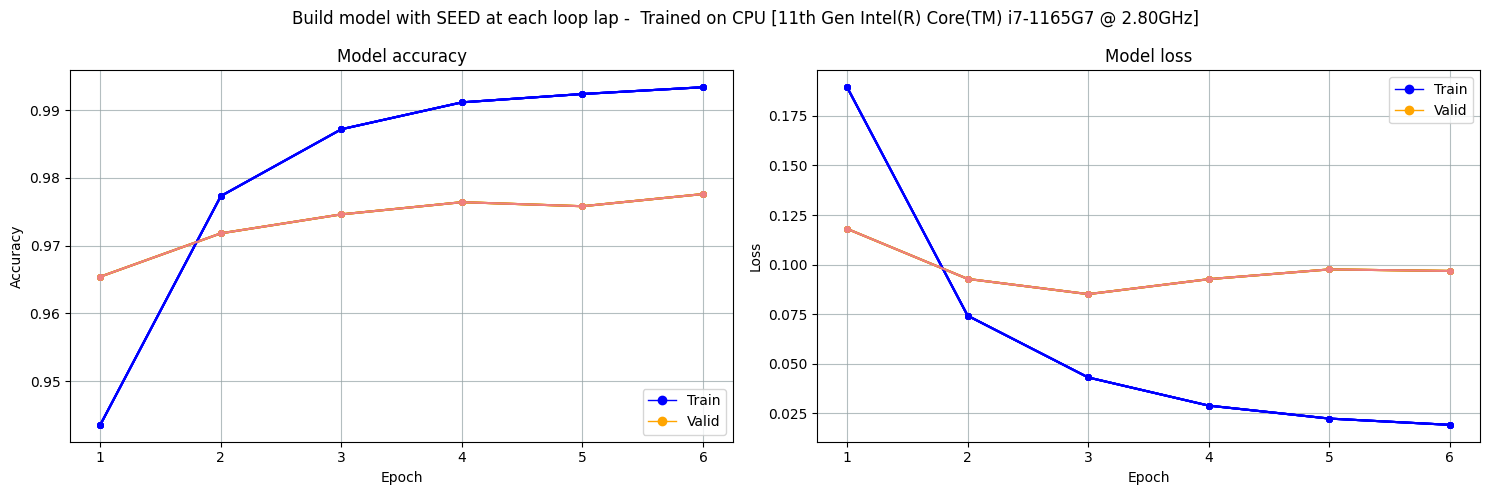

In [25]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
    
    # build a new network/
    model = build_DNN(1234)            # build a new network with a fixed SEED
    
    hist = model.fit(x_train, y_train, # images, labels
                     epochs=6,        # the total number of successive trainings
                     batch_size=32,    # split of the whole dadaset in batches
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')
plot_loss_accuracy(H, message='Build model with SEED at each loop lap')

$\leadsto$ the repoducibility is perfect &#128526;

### C - Reloading the model structure & weights with SEED at each loop lap $\leadsto$ reproducible

To avoid long computation time, you can skip running the next cell and just look at the result obtained on a core-i7 standard laptop:

<p style="text-align:center; font-style:italic; font-size:12px;">
      <img src="img/range5_reload_SEED1234_epochs10_bs32.png" alt="range5_reload_SEED1234_epochs10_bs32.png" style="width:1024px;"><br>
     [image credit: JLC]

In [27]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234.keras')

training #1
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9934 - loss: 0.0191 - val_accuracy: 0.9776 - val_loss: 0.0968
training #2
Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 -

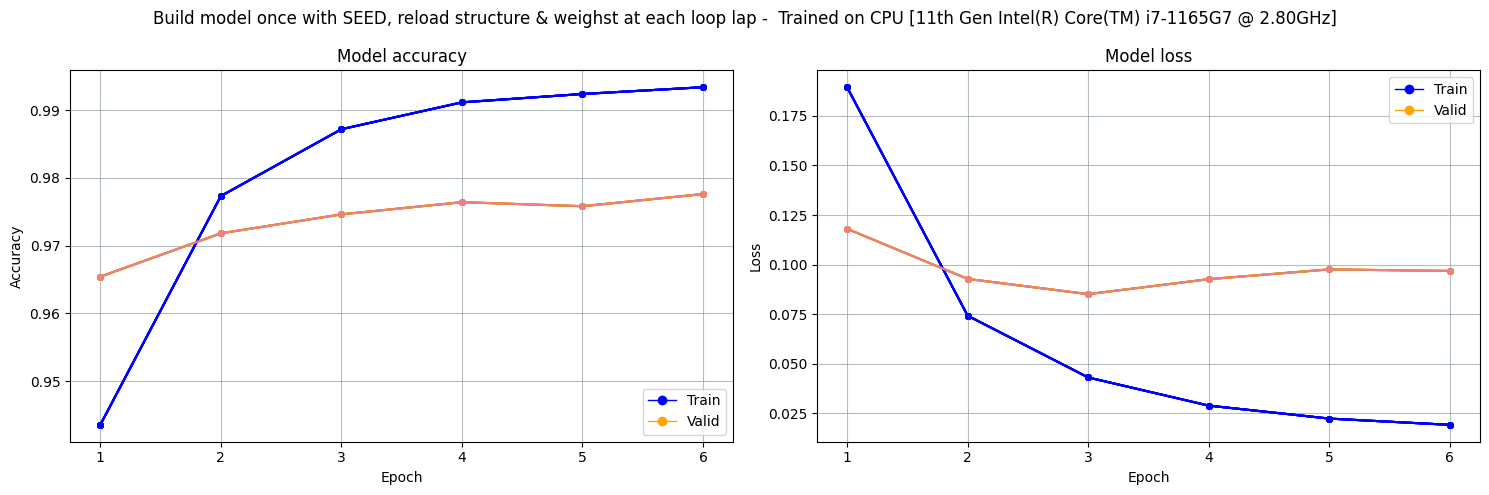

In [28]:
H, t0 = [], time()

for i in range(5):
    print(f"training #{i+1}")
                
    # reload the structure of the NN and its initial state 
    model = tf.keras.models.load_model('models/DNN_seed1234.keras') 
    
    # Deterministic tensorflow training: 
    tf.keras.utils.set_random_seed(1234) 
    tf.config.experimental.enable_op_determinism() 

    # train the network
    hist = model.fit(x_train, y_train, 
                     epochs=6, 
                     batch_size=32,
                     validation_data=(x_valid, y_valid), 
                     verbose=1)
    H.append(hist)  

print(f' Total Train {elapsed_time_since(t0)}')   
plot_loss_accuracy(H, message='Build model once with SEED, reload structure & weighst at each loop lap')

## 7 - Train the network

In [29]:
model = build_DNN(seed=1234)
model.save('models/DNN_seed1234.keras')

### Avoiding **over-fit** with **early-stop** of the training

Overfitting occurs when the model is trained too well on the training data but poorly performs on new unseen data. That kind of model tries to memorize the training data and fails to generalize on new unseen data.

Keras offers tools to automatically stop learning by monitoring for example the growth of `val_accuracy` or the decrease of `val_loss` from one epoch to another (see the _EarlyStopping_ callback).

We can thus define a list of callback functions that we pass as an argument to the `fit` method with the agument named _callbacks_:

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9435 - loss: 0.1895 - val_accuracy: 0.9654 - val_loss: 0.1180
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 - loss: 0.0742 - val_accuracy: 0.9718 - val_loss: 0.0928
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9872 - loss: 0.0430 - val_accuracy: 0.9746 - val_loss: 0.0851
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9764 - val_loss: 0.0926
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9924 - loss: 0.0223 - val_accuracy: 0.9758 - val_loss: 0.0976
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


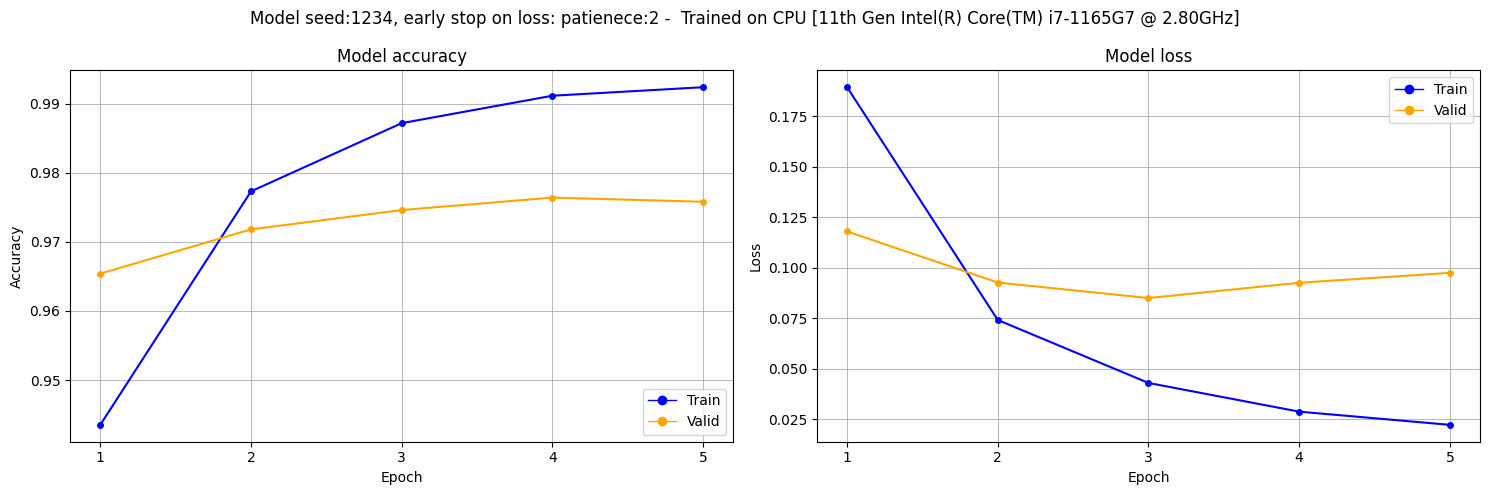

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from utils.tools import plot_loss_accuracy

PATIENCE = 2
SEED     = 1234

# define the list of 'callback' fucntions:
callbacks_list = [
    EarlyStopping(monitor='val_loss',  # The parameter to monitor
                  patience=PATIENCE,   # accept that 'val_accuracy' decrease 'patience' times
                  restore_best_weights=True,
                  verbose=1)
]

# load the network structure & initial weights:
model = tf.keras.models.load_model('models/DNN_seed1234.keras')

# Deterministic tensorflow training: 
tf.keras.utils.set_random_seed(1234)  # sets seeds for base-python, numpy and tf
tf.config.experimental.enable_op_determinism() 

hist = model.fit(x_train, y_train,
                 validation_data=(x_valid, y_valid), 
                 epochs=25,     # the total number of successive trainings
                 batch_size=32, # fragmentation of the whole dada set in batches
                 callbacks = callbacks_list)
plot_loss_accuracy(hist, message=f'Model seed:{SEED}, early stop on loss: patienece:{PATIENCE}')

### Save the trained model

In [31]:
model.save('models/DNN_seed1234_trained.keras')

## 8 - Evaluate the trained network <a name="6"></a>

#### Load the structure and weights of a trained model:

In [32]:
model = tf.keras.models.load_model('models/DNN_seed1234_trained.keras')

#### Evaluate the predictions of the model:

In [43]:
from sklearn.metrics import classification_report

# evaluate the model with the test dataset: 
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

# Predicting labels for test images
test_pred = model.predict(x_test)
predict_labels = np.argmax(test_pred, axis=-1)

# Display classification report
print("Classification Report:\n", classification_report(test_lab, predict_labels))

157/157 - 0s - 2ms/step - accuracy: 0.9768 - loss: 0.0743
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       490
           1       0.99      0.99      0.99       567
           2       0.99      0.97      0.98       516
           3       0.94      0.99      0.97       505
           4       0.97      0.97      0.97       491
           5       0.98      0.97      0.98       446
           6       1.00      0.97      0.98       479
           7       0.97      0.98      0.98       514
           8       0.98      0.97      0.98       487
           9       0.96      0.97      0.96       505

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



**precision**<br>
is the ratio $\displaystyle{\frac{tp}{tp + fp}}$ where $tp$ is the number of *true positives* and $fp$ the number of *false positives*.<br>
The precision is intuitively the ability of the classifier not to label a negative sample as positive.<br>
When does Precision matter most? When a False Positive is costly.

**recall**<br>
is the ratio $\displaystyle{\frac{tp}{tp + fn}}$ where $tp$ is the number of *true positives* and $fn$ the number of *false negatives*.<br>
The recall is intuitively the ability of the classifier to find all the positive samples.<br>
High Recall $\leadsto$ the model is thorough. It tries not to miss anything.<br>
When does Recall matter most? When a False Negative is costly.

**F$_\beta\$ - score** <br> 

F$_\beta$ - score can be interpreted as a weighted harmonic mean of the precision and recall, where an F$_\beta$-score reaches its best value at 1 and worst score at 0.<br>
$F_\beta = \frac{presion \times recall}{precision + recall}$<br>
The F$\bf_\beta$ - score weights recall more than precision by a factor of $\displaystyle{\beta}$. $\displaystyle{\beta}$ == 1.0 means recall and precision are equally important.<br>
When to use F1: When working with imbalanced data and want a single number to compare different models, without ignoring either type of error.

The support is the number of occurrences of each class in y_true.

### Show the confusion matrix

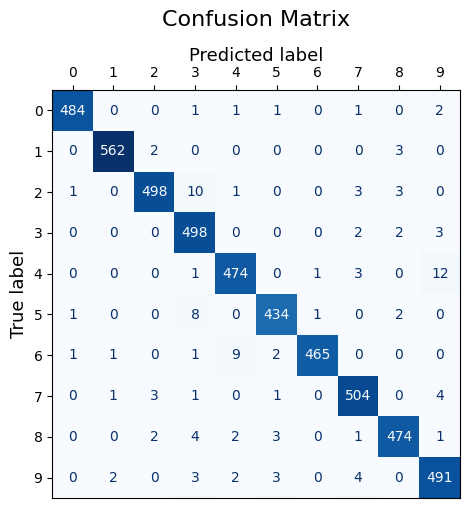

In [34]:
from utils.tools import show_conf_matrix
show_conf_matrix(test_lab, predict_labels, range(NB_CLASS), figsize=(7,6))

True Positive: &emsp; $\mathrm{TP}(k) = M(k,k)$  

False Positives: &emsp; $\mathrm{FP}(k) = \sum_{i \ne k} M(i,k)$

True Negatives: &emsp; $\mathrm{TN}(k) = \sum_{j \ne k} M(k, j)$

 Precision: &emsp; $\displaystyle{\mathrm{P}(k) = \frac{\mathrm{TP}(k)}{\mathrm{TP}(k) + \mathrm{FP}(k)}}$

In [47]:
from sklearn.metrics import log_loss
loss = log_loss(test_lab, test_pred)
print(f'model log loss: {loss:.2f}')

model log loss: 0.07
